In [1]:
import seaborn as sns
import matplotlib
import random
import os

from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
import math

import habitat_sim
from habitat_sim.utils import common as ut
from habitat_sim.utils import viz_utils as vut
import magnum as mn
from habitat_sim.geo import Ray
from habitat_sim.nav import ShortestPath
from magnum import Vector3
import cv2

from habitat.utils.visualizations.maps import (
    get_topdown_map_from_sim,
    colorize_topdown_map,
    draw_agent,
    to_grid,
)

class HabitatSimBuilder():
    def __init__(self):
        self.sim = None
        self.obj_attr_mgr = None
        self.prim_attr_mgr = None
        self.stage_attr_mgr = None
        self.sel_file_obj_handle = None
        self.sel_prim_obj_handle = None
        self.sel_asset_handle = None
        self.ball_id = None
        self.object_ids = []
        # --- paramètres pour la top-down map ---
        self.map_size         = 200         # taille de la carte (px × px)
        self.meters_per_pixel = 0.1 # résolution en m/pixel
        # grille booléenne accumulant toutes les cases « libres » déjà vues
        self.visited_map = np.zeros((self.map_size, self.map_size), dtype=bool)

    ######### Configuration Utility functions ######

    def make_cfg(self, settings):
        sim_cfg = habitat_sim.SimulatorConfiguration()
        sim_cfg.gpu_device_id = 0
        sim_cfg.scene_id = settings["scene"]
        sim_cfg.enable_physics = settings["enable_physics"]
        
        sensor_settings = {
            "height": 256, "width": 256,  # Spatial resolution of observations
            "sensor_height": 0.15,  # Height of sensors in meters, relative to the agent
        }

        # Create a RGB sensor configuration
        rgb_sensor_spec = habitat_sim.CameraSensorSpec()
        rgb_sensor_spec.uuid = "color_sensor"
        rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
        rgb_sensor_spec.resolution = [sensor_settings["height"], sensor_settings["width"]]
        rgb_sensor_spec.position = [0.0, sensor_settings["sensor_height"], 0.0]
        rgb_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE

        # Create a depth sensor configuration
        depth_sensor_spec = habitat_sim.CameraSensorSpec()
        depth_sensor_spec.uuid = "depth_sensor"
        depth_sensor_spec.sensor_type = habitat_sim.SensorType.DEPTH
        depth_sensor_spec.resolution = [sensor_settings["height"], sensor_settings["width"]]
        depth_sensor_spec.position = [0.0, sensor_settings["sensor_height"], 0.0]
        depth_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE

        # Create a Semantic sensor configuration
        semantic_sensor_spec = habitat_sim.CameraSensorSpec()
        semantic_sensor_spec.uuid = "semantic_sensor"
        semantic_sensor_spec.sensor_type = habitat_sim.SensorType.SEMANTIC
        semantic_sensor_spec.resolution = [sensor_settings["height"], sensor_settings["width"]]
        semantic_sensor_spec.position = [0.0, sensor_settings["sensor_height"], 0.0]
        semantic_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE

        sensor_specs = [rgb_sensor_spec, depth_sensor_spec, semantic_sensor_spec]
        print(">>>>>> Added all sensors in array sensor_spec")
        # Here you can specify the amount of displacement in a forward action and the turn angle

        agent_settings = {
            "action_space": {
                "move_forward": 0.25, "move_backward": 0.25,  # Distance to cover in a move action in meters
                "turn_left": 30.0, "turn_right": 30,  # Angles to cover in a turn action in degrees
            }
        }

        agent_cfg = habitat_sim.agent.AgentConfiguration()
        print(">>>>>> Creating agent cfg")
        agent_cfg.action_space = {
            k: habitat_sim.agent.ActionSpec(
                k, habitat_sim.agent.ActuationSpec(amount=v)
            ) for k, v in agent_settings["action_space"].items()
        }
        agent_cfg.sensor_specifications = sensor_specs
        print(">>>>>> Added sensor_spec to agent_cfg")

        return habitat_sim.Configuration(sim_cfg, [agent_cfg])

    def make_default_settings(self):
        settings = {
            "width": 720,  # Spatial resolution of the observations
            "height": 544,
            "scene": "./data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb",  # Scene path
            "default_agent": 0,
            "sensor_height": 1.5,  # Height of sensors in meters
            "sensor_pitch": -np.pi / 8.0,  # sensor pitch (x rotation in rads)
            "color_sensor_1st_person": True,  # RGB sensor
            "color_sensor_3rd_person": False,  # RGB sensor 3rd person
            "depth_sensor_1st_person": False,  # Depth sensor
            "semantic_sensor_1st_person": True,  # Semantic sensor
            "seed": 1,
            "enable_physics": True,  # enable dynamics simulation
        }
        return settings

    def make_simulator_from_settings(self, sim_settings):


        # UI-populated handles used in various cells.  Need to initialize to valid
        # value in case IPyWidgets are not available.
        # Holds the user's desired file-based object template handle
        self.sel_file_obj_handle = self.obj_attr_mgr.get_file_template_handles()[0]
        # Holds the user's desired primitive-based object template handle
        self.sel_prim_obj_handle = self.obj_attr_mgr.get_synth_template_handles()[0]
        # Holds the user's desired primitive asset template handle
        self.sel_asset_handle = self.prim_attr_mgr.get_template_handles()[0]

    ############ Simulation Utility functions ############

    def remove_all_objects(self):
        for obj_id in self.object_ids:
            self.sim.remove_object(obj_id)
        self.object_ids.clear()


    def simulate(self, sim, dt=1.0, get_frames=True):
        # simulate dt seconds at 60Hz to the nearest fixed timestep
        print("Simulating " + str(dt) + " world seconds.")
        observations = []
        start_time = sim.get_world_time()
        while sim.get_world_time() < start_time + dt:
            sim.step_physics(1.0 / 60.0)
            if get_frames:
                observations.append(sim.get_sensor_observations())
        return observations

    # Set an object transform relative to the agent state
    def set_object_state_from_agent(
        self,
        sim,
        ball_id,
        offset=np.array([0, 2.0, -1.5]),
        orientation=mn.Quaternion(((0, 0, 0), 1)),
    ):
         # récupère l’objet instancié
        rigid_mgr = self.sim.get_rigid_object_manager()
        ball_obj = rigid_mgr.get_object_by_id(ball_id)   # ou add_object_by_template_id renvoie déjà l’objet
        
        # calcule la position dans le monde
        agent_tf    = self.sim.agents[0].scene_node.transformation_matrix()
        world_pos   = agent_tf.transform_point(offset)

        ball_obj.translation = world_pos
        ball_obj.rotation    = orientation

    # A utility function for displaying observations
    def display_obs(self, rgb_obs: np.ndarray, depth_obs: np.ndarray, sem_obs: np.ndarray):
        img_arr, title_arr = [], []
        
        rgb_img = Image.fromarray(rgb_obs, mode="RGBA")
        img_arr.append(rgb_img)
        title_arr.append("rgb")
        
        depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
        img_arr.append(depth_img)
        title_arr.append("depth")


        # Semantic : on fait notre propre palette
        # sem_obs : H×W d'entiers (0,1,…)
        H, W = sem_obs.shape
        sem_color = np.zeros((H, W, 4), dtype=np.uint8)

        # palette simple : 0 → transparent (background), 1 → rouge semi-opaque
        sem_color[sem_obs == 0] = [0,   0,   0,   0]    # background transparent
        sem_color[sem_obs == 1] = [255, 0,   0, 127]    # balle en rouge à 50% d'alpha

        sem_img = Image.fromarray(sem_color, mode="RGBA")
        
        # --- 2) Affichage 1×3 ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for ax in axes:
            ax.axis("off")

        axes[0].set_title("RGB")
        axes[0].imshow(rgb_img)

        axes[1].set_title("Depth")
        axes[1].imshow(depth_img, cmap="gray")

        axes[2].set_title("Semantic")
        axes[2].imshow(sem_img)

        plt.show(block=False)

    def get_360_lidar_scan(self,
                           sim,
                      num_rays: int = 360,
                      max_range: float = 12.0,
                      height: float = 0.15):
        # 1) On récupère le node et sa rotation complète (Quaternion)
        node = sim.agents[0].scene_node
        q    = node.rotation
        mat  = node.absolute_transformation()

        # 2) Origine du lidar
        p      = mat.translation
        origin = mn.Vector3(p.x, p.y + height, p.z)

        # 3) Angles locaux entre -π et +π
        angles = np.linspace(-np.pi, np.pi, num_rays, endpoint=False)
        dists  = np.empty(num_rays, dtype=np.float32)

        for i, θ in enumerate(angles):
            # 4) direction LOCALE 0→avant = (0,0,-1), tournée de θ autour de Y
            local_dir = mn.Vector3(np.sin(θ), 0.0, -np.cos(θ))

            # 5) on applique la rotation complète du robot
            #    c'est équivalent à q * local_dir * q^{-1}
            world_dir = q.transform_vector(local_dir)
            world_dir.y = 0.0
            world_dir = world_dir.normalized()

            # 6) cast
            ray    = Ray(origin, world_dir)
            result = sim.cast_ray(ray)
            distance = result.hits[0].ray_distance
            #print("has hit ? ", result.has_hits(), "distance = ", distance)
            dists[i] = min(distance, max_range)

        return angles, dists
    

    def euler_from_quaternion(self, q: mn.Quaternion) -> float:
        x, y, z = q.vector     # mn.Quaternion stocke (x,y,z) dans q.vector
        w       = q.scalar     # et le scalaire dans q.scalar
        siny =  2 * (w*y + x*z)
        cosy =  1 - 2 * (y*y + z*z)
        return math.atan2(siny, cosy)
    
    def get_agent_position(self) :
        t = self.sim.agents[0].scene_node.absolute_transformation().translation
        return np.array([t.x, t.y, t.z], dtype=np.float32)
    
    def get_agent_to_ball_dist(self):
        t = self.ball_id.translation
        return np.linalg.norm(self.get_agent_position() - np.array([t.x, t.y, t.z], dtype=np.float32))
    
    def render_map(self):
        img = self._get_topdown_with_history_and_agent()
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

    def _get_topdown_with_history_and_agent(self):
        # --- 1) Récupère la top-down occupancy map (0=invalid,1=free,2=border) ---
        occ_map = get_topdown_map_from_sim(
            self.sim,
            map_resolution=self.map_size,
            draw_border=True,
            meters_per_pixel=self.meters_per_pixel,
            agent_id=0,
        )  # shape: (H, W) int :contentReference[oaicite:0]{index=0}

        H, W = occ_map.shape

        # --- 2) (Re)crée visited_map si la résolution a changé ---
        if self.visited_map is None or self.visited_map.shape != (H, W):
            self.visited_map = np.zeros((H, W), dtype=bool)

        # --- 3) Met à jour l'historique des cases libres explorées ---
        free_mask = (occ_map == 1)

        # 4) Calcule la position de l’agent en grille
        t = self.sim.agents[0].scene_node.absolute_transformation().translation
        col, row = to_grid(
            realworld_x=t.x,
            realworld_y=t.z,
            grid_resolution=(W, H),
            sim=self.sim,
        )

        q  = self.sim.agents[0].scene_node.rotation
        w  = q.scalar; vx, vy, vz = q.vector.x, q.vector.y, q.vector.z
        yaw = math.atan2(2*(w*vy + vx*vz), 1 - 2*(vy*vy + vz*vz))

        # --- 4) génère mask de visibilité (FOV + LOS) ---
        sensor_radius_m = 3.0
        radius_px = int(sensor_radius_m / self.meters_per_pixel)
        fov = math.radians(45)  # 45° de chaque côté

        # 5) création du grid local centré sur l’agent
        r_min = max(0, row - radius_px)
        r_max = min(H, row + radius_px + 1)
        c_min = max(0, col - radius_px)
        c_max = min(W, col + radius_px + 1)
        grid_cols, grid_rows = np.meshgrid(
            np.arange(c_min, c_max), np.arange(r_min, r_max)
        )
        dx = grid_cols - col
        dy = row - grid_rows

        # 6) masque du cercle
        circle = (dx*dx + dy*dy) <= (radius_px*radius_px)
        rel_x = dx[circle]
        rel_y = dy[circle]

        # 7) filtrage FOV
        angles = np.arctan2(rel_y, rel_x)
        diffs = (angles - yaw + np.pi) % (2*np.pi) - np.pi
        in_fov = np.abs(diffs) <= (fov/2)

        # 8) LOS simple par Bresenham
        def los(r0, c0, r1, c1):
            steep = abs(r1-r0) > abs(c1-c0)
            if steep:
                r0, c0, r1, c1 = c0, r0, c1, r1
            dr = abs(r1-r0); dc = abs(c1-c0)
            err = dc//2; ystep = 1 if r0<r1 else -1
            xstep = 1 if c0<c1 else -1
            y = r0
            for x in range(c0, c1, xstep):
                rr, cc = (y, x) if not steep else (x, y)
                if not (0 <= rr < H and 0 <= cc < W and free_mask[rr,cc]):
                    return False
                err -= dr
                if err < 0:
                    y += ystep
                    err += dc
            return True

        vis_mask = np.zeros((H, W), dtype=bool)
        rows_cand = grid_rows[circle][in_fov] + r_min
        cols_cand = grid_cols[circle][in_fov] + c_min
        for r_, c_ in zip(rows_cand, cols_cand):
            if los(row, col, r_, c_):
                vis_mask[r_, c_] = True

        # 9) mise à jour historique
        self.visited_map |= (free_mask & vis_mask)

        # 10) colorisation et surcouche historique
        topdown_rgb = colorize_topdown_map(occ_map)
        overlay = topdown_rgb.copy()
        overlay[self.visited_map] = (0, 255, 0)
        topdown_rgb = cv2.addWeighted(overlay, 0.3, topdown_rgb, 0.7, 0)

        # 11) zone visible (gris)
        topdown_bgr = cv2.cvtColor(topdown_rgb, cv2.COLOR_RGB2BGR)
        tmp = topdown_bgr.copy()
        tmp[vis_mask] = (128, 128, 128)
        topdown_bgr = cv2.addWeighted(tmp, 0.5, topdown_bgr, 0.5, 0)

        # 12) dessine l’agent en rouge
        cv2.circle(topdown_bgr, (col, row), 6, (0, 0, 255), thickness=-1)


        
        '''# 5) Crée un masque local = cercle de visibilité du capteur
        sensor_radius_m = 3.0  # à ajuster à ton lidar
        radius_px = int(sensor_radius_m / self.meters_per_pixel)
        local_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(local_mask, (col, row), radius_px, 1, thickness=-1)
        local_mask = local_mask.astype(bool)
        # 6) N’ajoute à l’historique que les nouvelles cellules libres **dans** le rayon
        new_seen = free_mask & local_mask
        self.visited_map |= new_seen

        # 7) Colorise la carte et superpose l’historique en vert
        topdown_rgb = colorize_topdown_map(occ_map)  # H×W×3 RGB
        overlay = topdown_rgb.copy()
        overlay[self.visited_map] = (0, 255, 0)      # vert en RGB
        topdown_rgb = cv2.addWeighted(overlay, 0.3, topdown_rgb, 0.7, 0)

        # 8) Passe en BGR pour OpenCV
        topdown_bgr = cv2.cvtColor(topdown_rgb, cv2.COLOR_RGB2BGR)

        # 9) Dessine la zone visible (cercle gris semi-transparent)
        circ_ovl = topdown_bgr.copy()
        cv2.circle(circ_ovl, (col, row), radius_px, (128, 128, 128), thickness=-1)
        topdown_bgr = cv2.addWeighted(circ_ovl, 0.5, topdown_bgr, 0.5, 0)

        # 10) Extrait le yaw correctement (scalar/vector sont des propriétés)
        q   = self.sim.agents[0].scene_node.rotation
        w   = q.scalar
        vx  = q.vector.x
        vy  = q.vector.y
        vz  = q.vector.z
        siny = 2 * (w * vy + vx * vz)
        cosy = 1 - 2 * (vy * vy + vz * vz)
        yaw  = math.atan2(siny, cosy)

        # 11) Trace l’agent en rouge (plus gros pour être visible)
        topdown_bgr = draw_agent(
            topdown_bgr,
            agent_center_coord=(col, row),
            agent_rotation=yaw,
            agent_radius_px=6,
        )'''

        # 12) Retourne en RGB pour Matplotlib

        # --- 7) Retourne en RGB pour Matplotlib ---
        return cv2.cvtColor(topdown_bgr, cv2.COLOR_BGR2RGB)

>>>>>> Added all sensors in array sensor_spec
>>>>>> Creating agent cfg
>>>>>> Added sensor_spec to agent_cfg
[19:54:18:603167]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[19:54:18:603369]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[19:54:18:603441]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[19:54:18:603487]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[19:54:18:6035

[19:54:18:717346]:[Assets] ResourceManager.cpp(355)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SceneInstanceAttributes-provided name : data/scene_datasets/cantwell/Cantwell.scn  nor constructed filename : data/scene_datasets/cantwell/info_semantic.json exist on disk.
[19:54:22:763119]:[Sim] Simulator.cpp(474)::instanceStageForSceneAttributes : 
---
The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0  
---
[19:54:22:793147]:[Physics] PhysicsManager.cpp(281)::addObject : Simplified template handle : ball  | newObjectHandle : ball_:0000


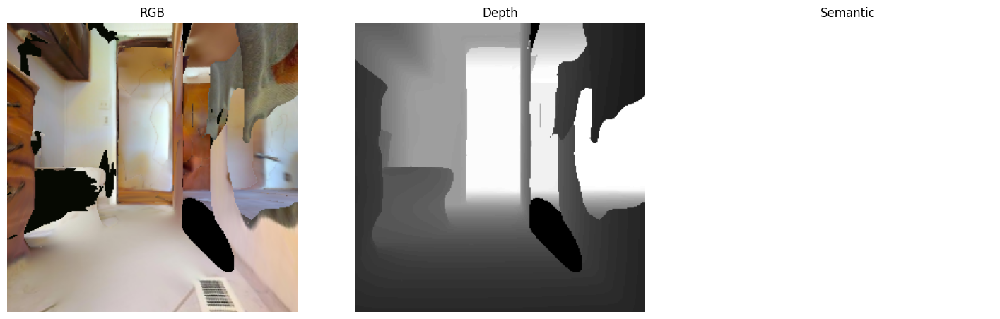

Ball world position : Vector(0.00818682, 0.15752, -3.89367)
Agent world position: Vector(-1.85621, 0.30776, 0.443244)
Ball relative to agent: Vector(1.8644, -0.15024, -4.33691)


Use TGFH to control the agent now:  g


Choose to move_backward
Unique semantic values: [0]


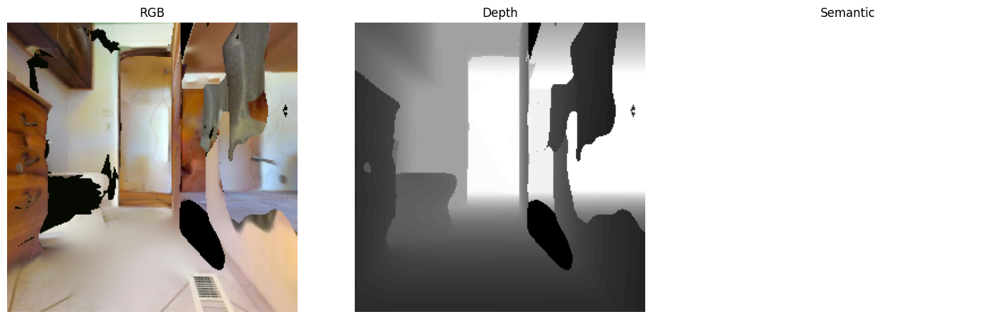

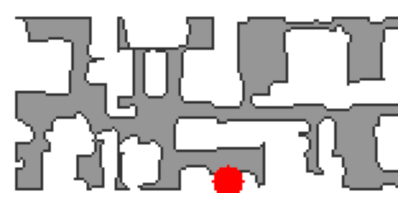

Agent world position: Vector(-1.85621, 0.358252, 0.531605)
Ball world position : Vector(0.00822089, 0.154821, -3.89366)
Ball relative to agent: 4.806291580200195


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


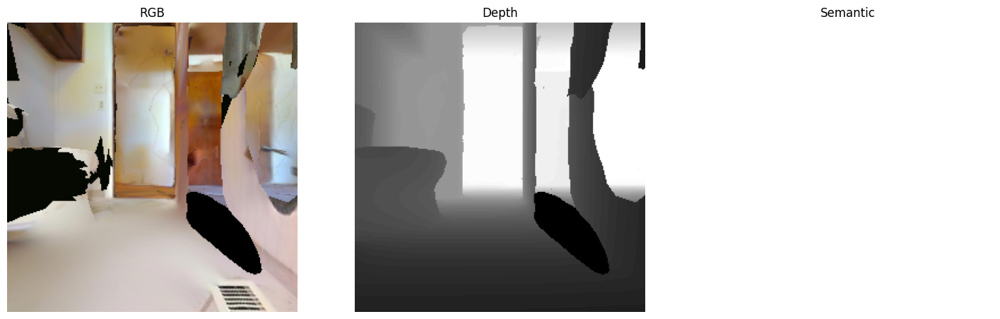

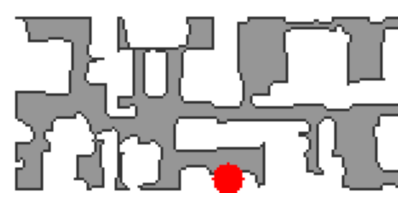

Agent world position: Vector(-1.85621, 0.194998, 0.281605)
Ball world position : Vector(0.00818565, 0.154796, -3.8939)
Ball relative to agent: 4.573011875152588


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


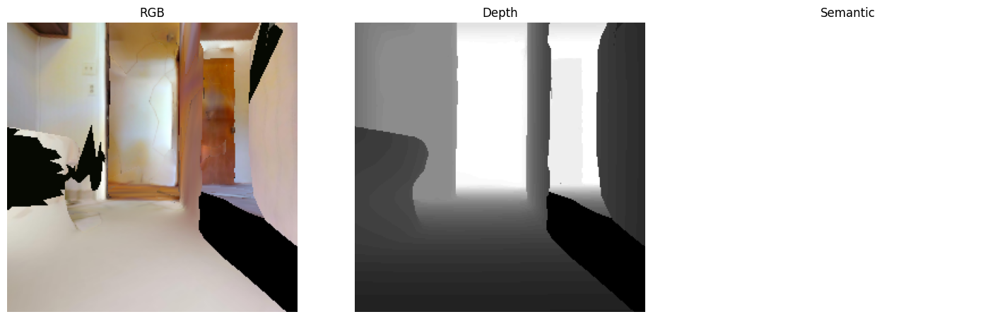

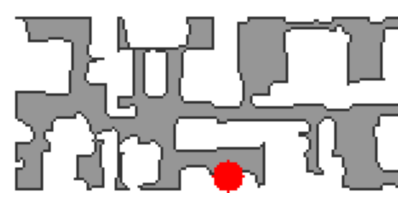

Agent world position: Vector(-1.85621, 0.158252, 0.0316048)
Ball world position : Vector(0.00813432, 0.154759, -3.89425)
Ball relative to agent: 4.346050262451172


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


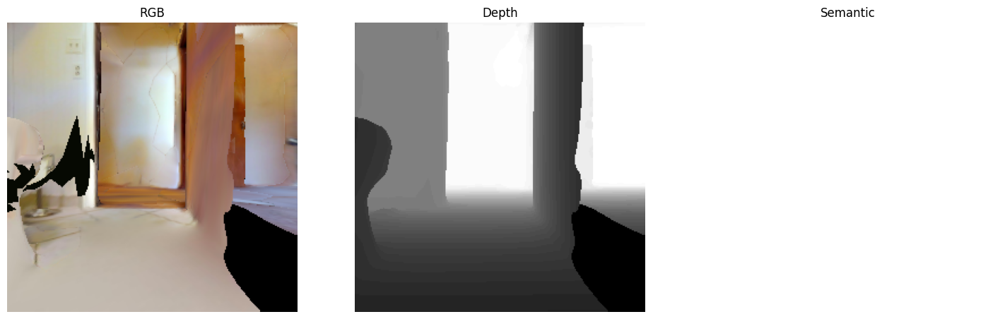

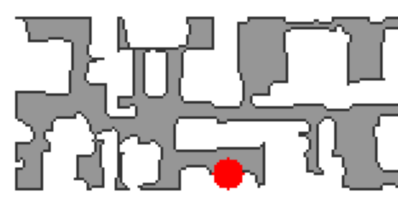

Agent world position: Vector(-1.85621, 0.158252, -0.218395)
Ball world position : Vector(0.00806637, 0.154708, -3.89472)
Ball relative to agent: 4.122000694274902


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


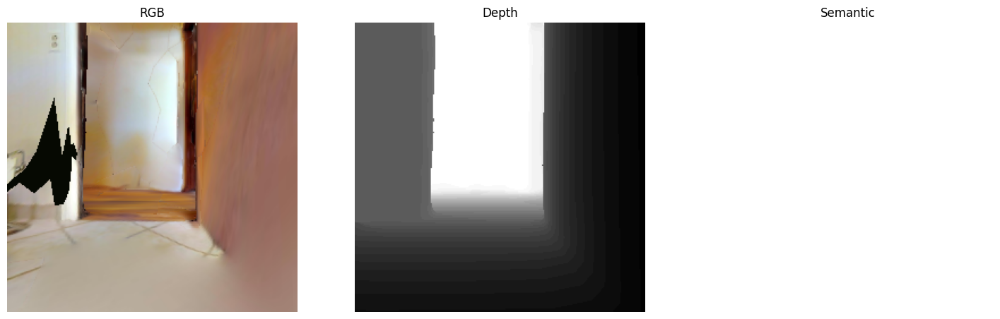

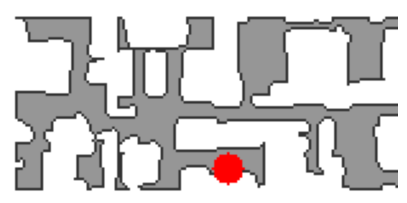

Agent world position: Vector(-1.85621, 0.158252, -0.468395)
Ball world position : Vector(0.00798446, 0.154591, -3.89529)
Ball relative to agent: 3.9011385440826416


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


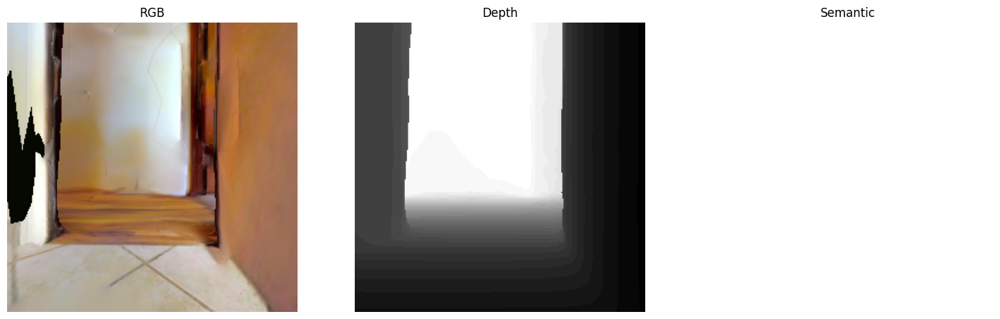

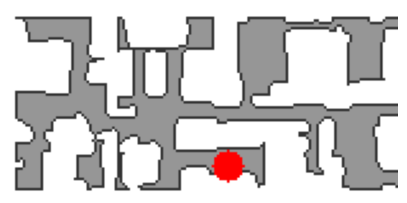

Agent world position: Vector(-1.85621, 0.158252, -0.718395)
Ball world position : Vector(0.00789113, 0.154466, -3.89599)
Ball relative to agent: 3.684016466140747


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


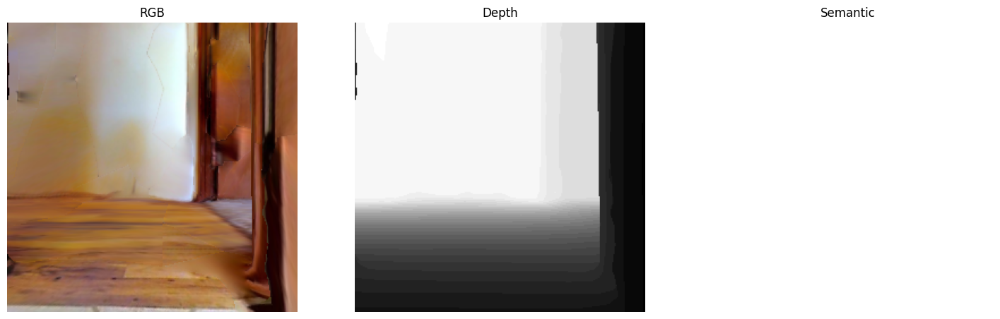

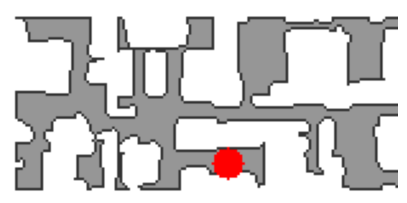

Agent world position: Vector(-1.85621, 0.158252, -0.968395)
Ball world position : Vector(0.00778426, 0.154396, -3.8968)
Ball relative to agent: 3.471318006515503


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


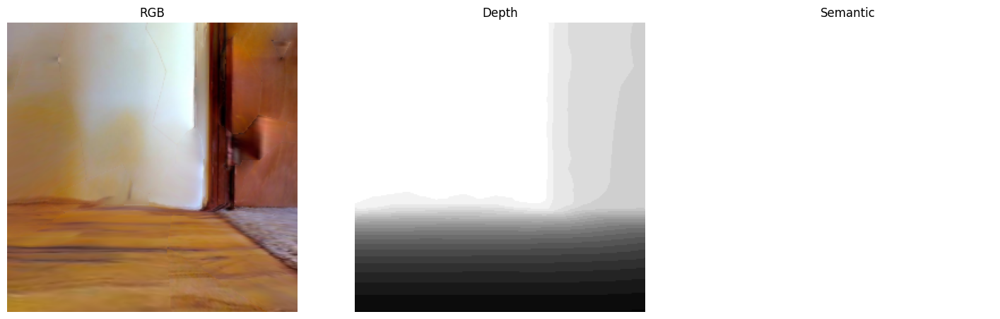

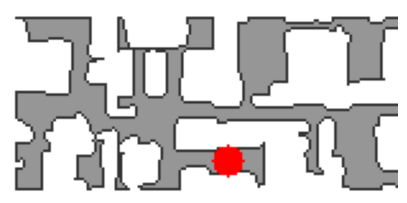

Agent world position: Vector(-1.85621, 0.158252, -1.2184)
Ball world position : Vector(0.00766099, 0.154344, -3.89774)
Ball relative to agent: 3.2638797760009766


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


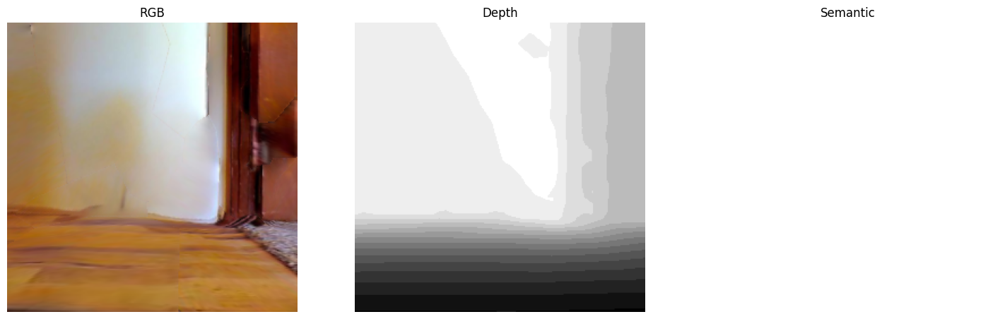

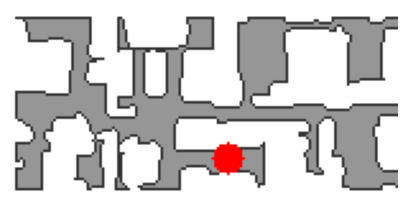

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00753367, 0.154029, -3.89878)
Ball relative to agent: 3.062734365463257


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


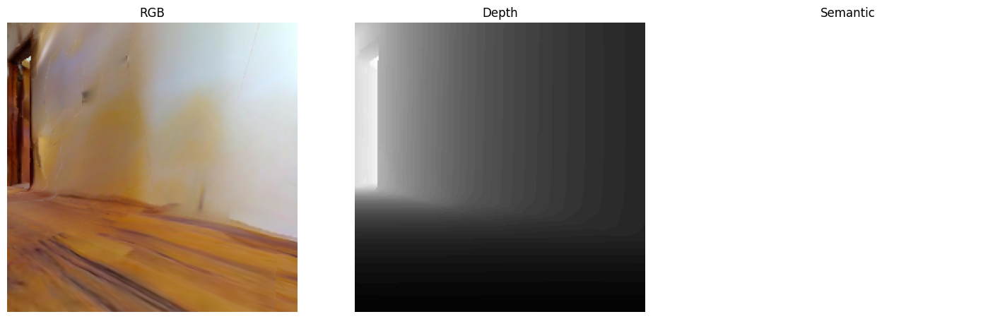

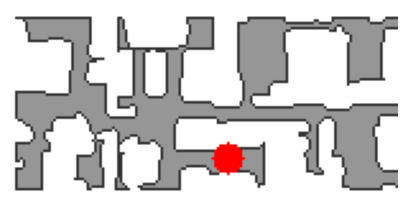

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00738623, 0.153968, -3.89998)
Ball relative to agent: 3.0635976791381836


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


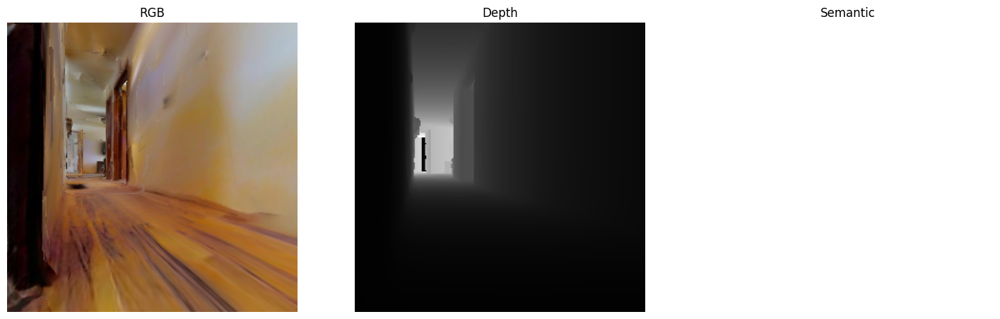

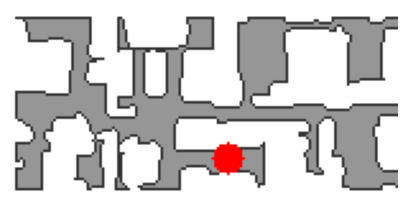

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00723, 0.153863, -3.90132)
Ball relative to agent: 3.0645627975463867


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


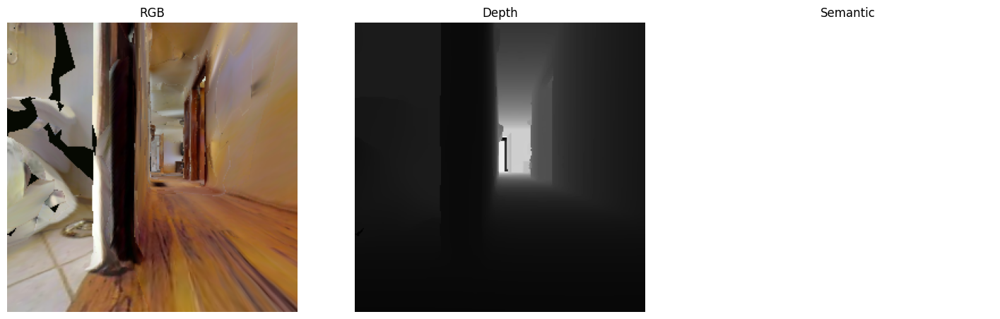

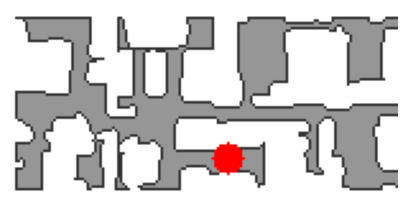

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.0070679, 0.15371, -3.90278)
Ball relative to agent: 3.065627336502075


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


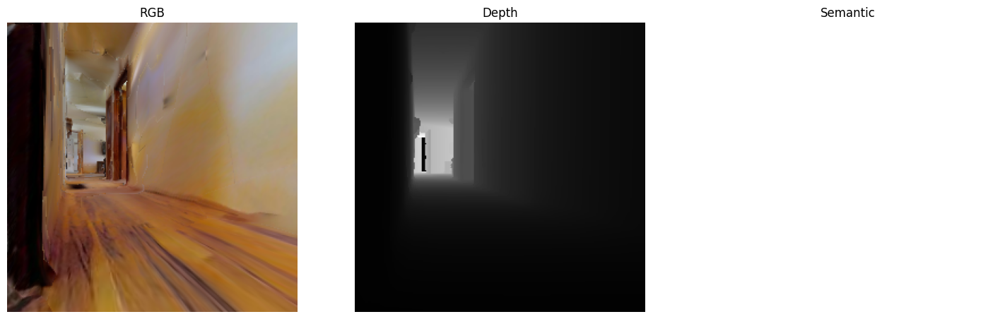

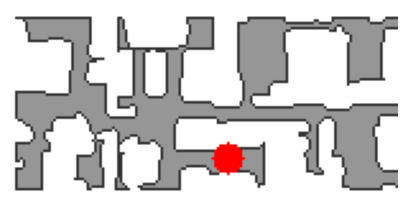

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00689905, 0.153899, -3.90417)
Ball relative to agent: 3.066626787185669


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


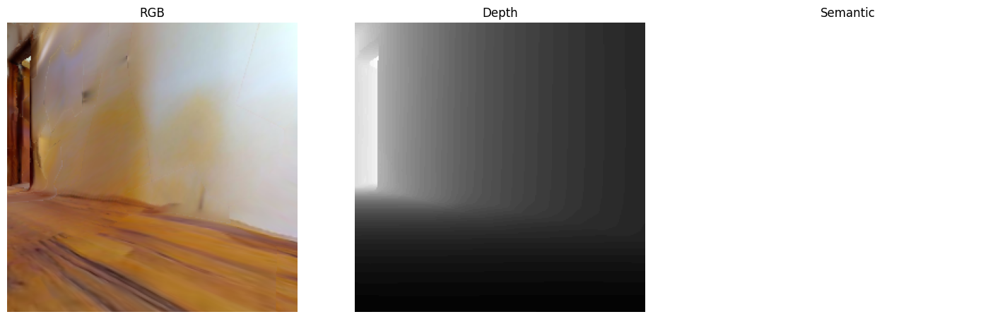

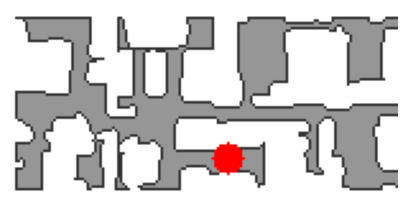

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00672591, 0.154053, -3.90546)
Ball relative to agent: 3.0675437450408936


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


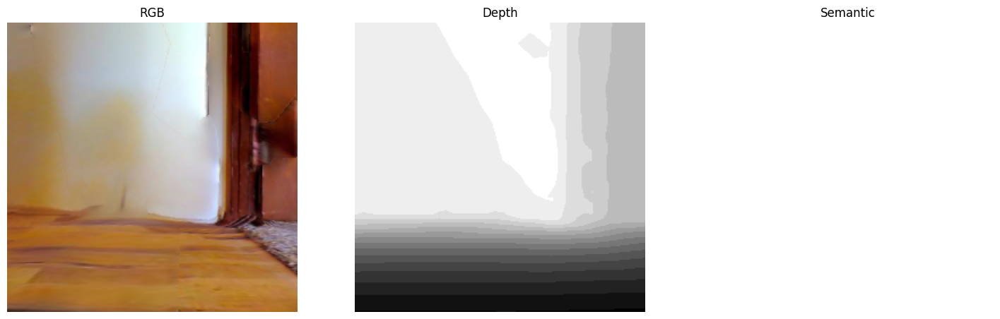

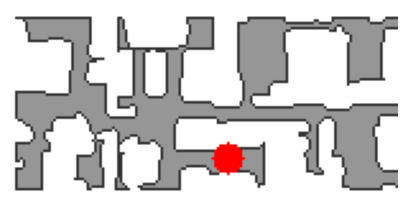

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.0065403, 0.154298, -3.90665)
Ball relative to agent: 3.0683774948120117


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


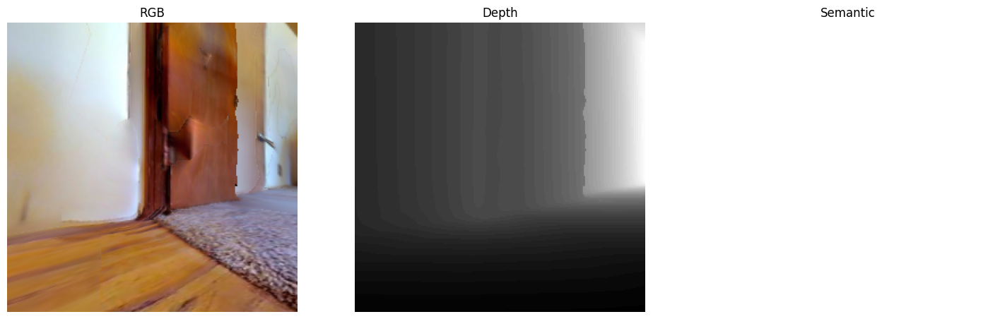

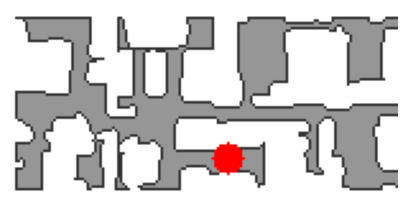

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00634875, 0.154368, -3.90777)
Ball relative to agent: 3.06915283203125


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


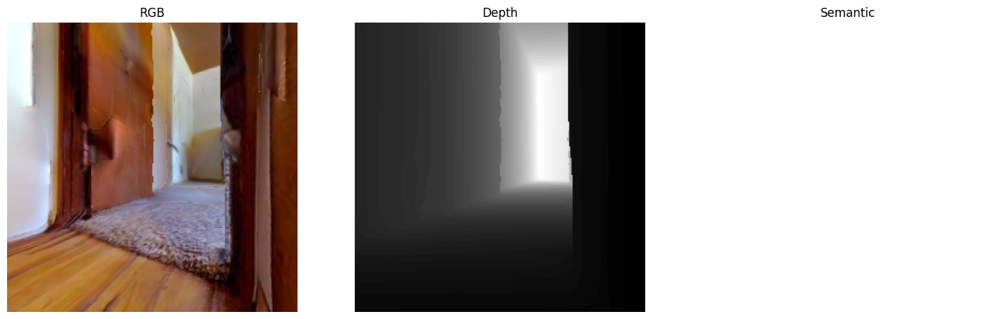

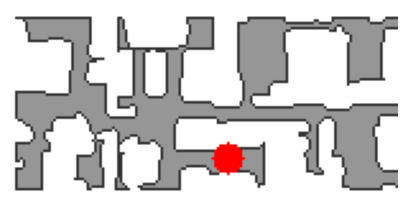

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00614143, 0.154433, -3.90882)
Ball relative to agent: 3.0698578357696533


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


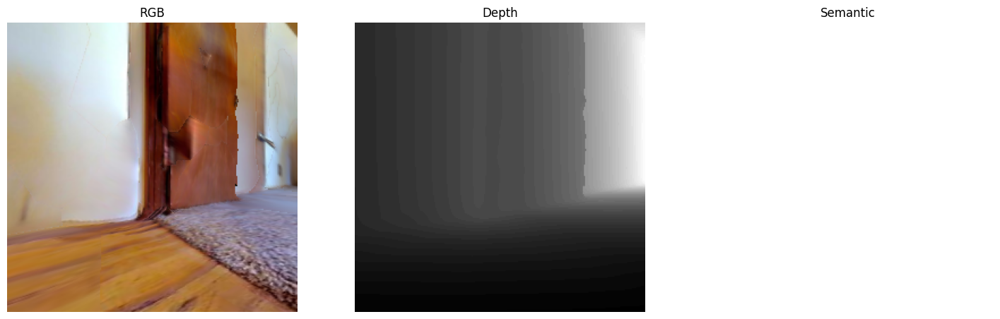

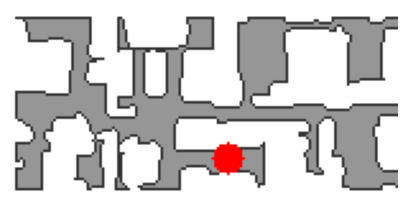

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00591179, 0.15453, -3.90978)
Ball relative to agent: 3.070488214492798


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


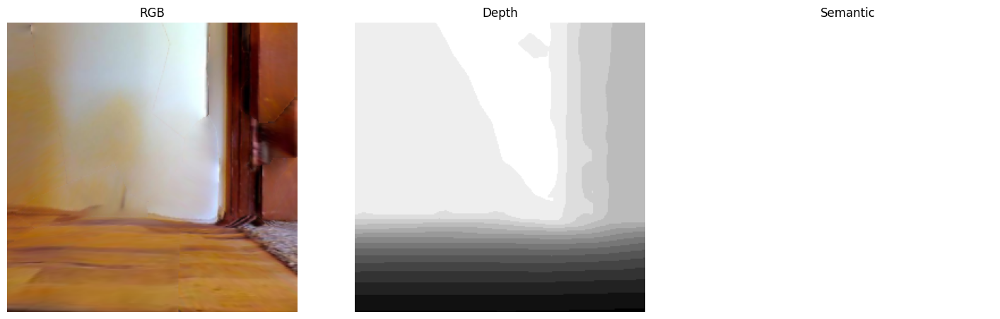

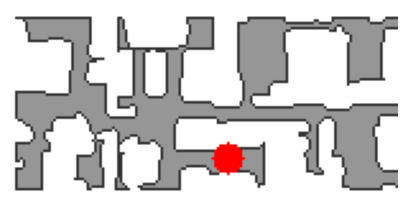

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.0056627, 0.154592, -3.91069)
Ball relative to agent: 3.071056365966797


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


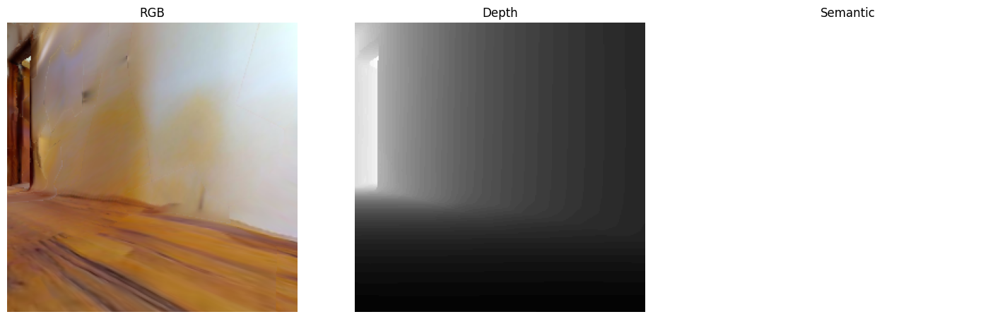

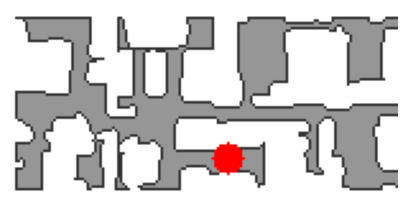

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00538774, 0.154678, -3.91153)
Ball relative to agent: 3.071561098098755


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


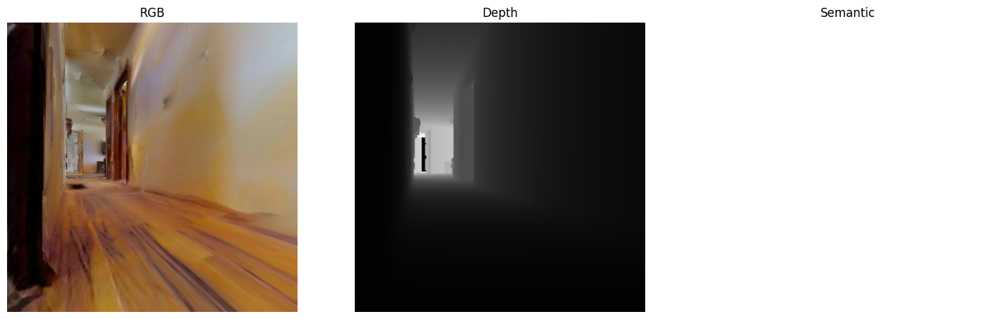

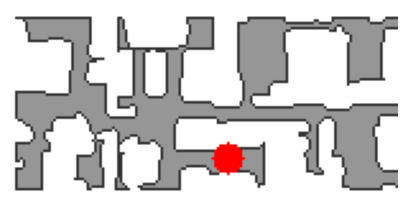

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00509163, 0.154717, -3.91232)
Ball relative to agent: 3.0720083713531494


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


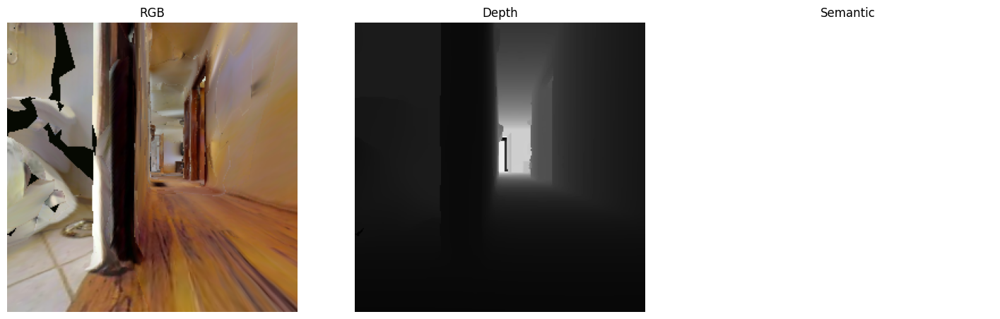

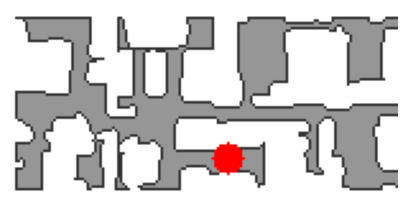

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00477337, 0.154738, -3.91306)
Ball relative to agent: 3.0724050998687744


Use TGFH to control the agent now:  h


Choose to turn_right
Unique semantic values: [0]


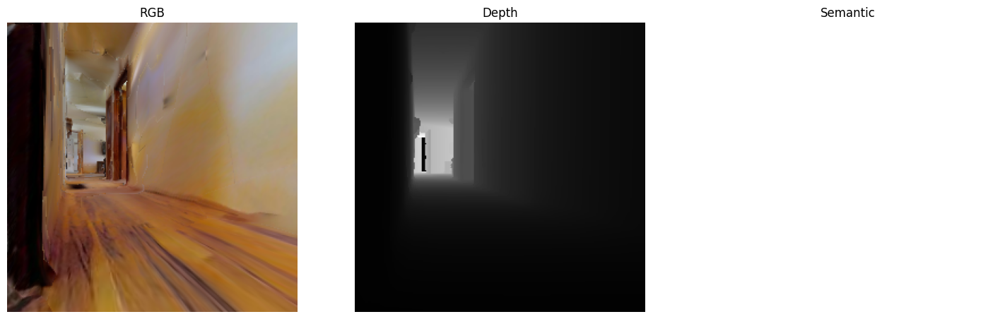

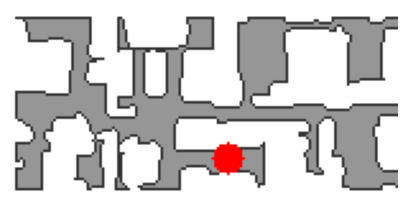

Agent world position: Vector(-1.85621, 0.158252, -1.4684)
Ball world position : Vector(0.00442899, 0.154767, -3.91375)
Ball relative to agent: 3.0727477073669434


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


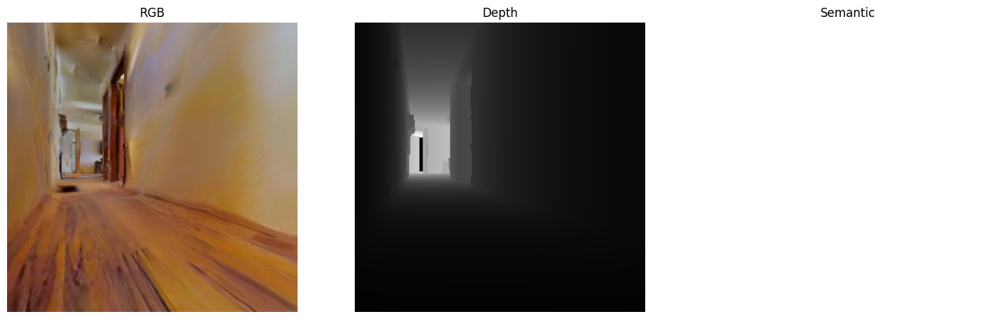

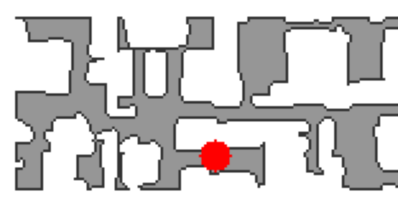

Agent world position: Vector(-2.07272, 0.158252, -1.5934)
Ball world position : Vector(0.00405608, 0.154774, -3.9144)
Ball relative to agent: 3.114494800567627


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


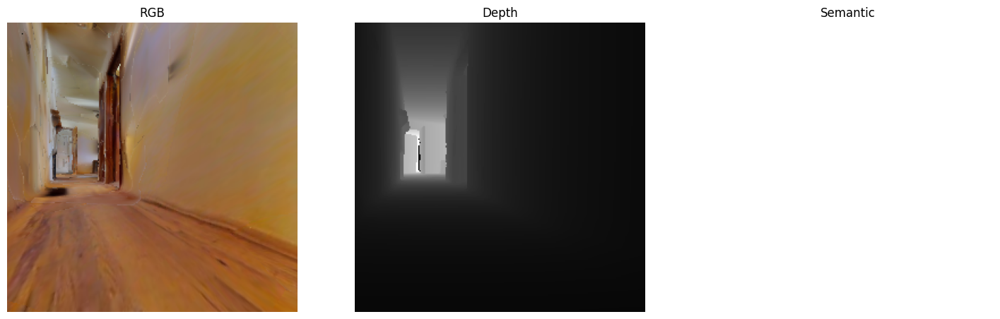

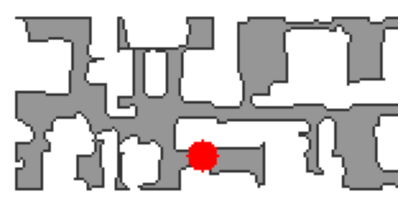

Agent world position: Vector(-2.28923, 0.158252, -1.7184)
Ball world position : Vector(0.00365538, 0.154692, -3.91501)
Ball relative to agent: 3.1752843856811523


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


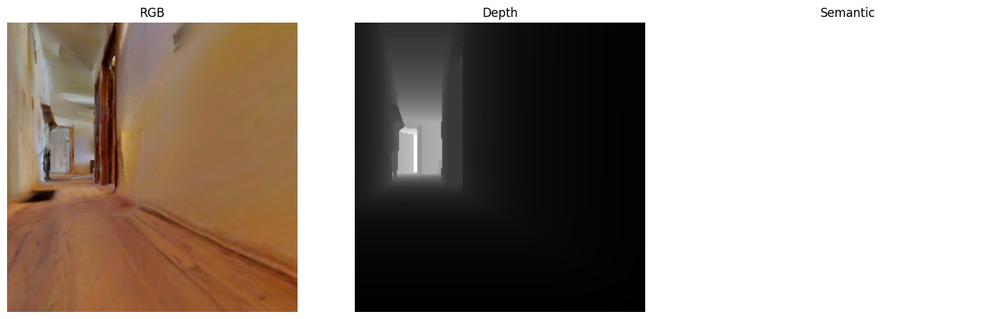

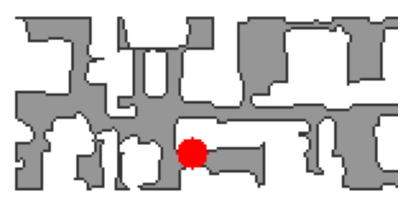

Agent world position: Vector(-2.50573, 0.158252, -1.8434)
Ball world position : Vector(0.00321375, 0.154732, -3.91559)
Ball relative to agent: 3.254042625427246


Use TGFH to control the agent now:  f


Choose to turn_left
Unique semantic values: [0]


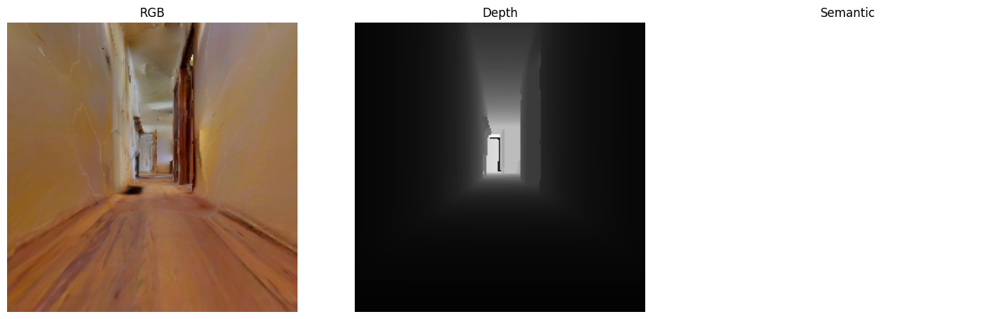

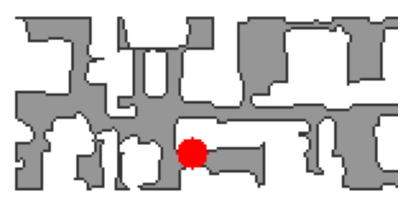

Agent world position: Vector(-2.50573, 0.158252, -1.8434)
Ball world position : Vector(0.00276228, 0.155, -3.91612)
Ball relative to agent: 3.2540369033813477


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


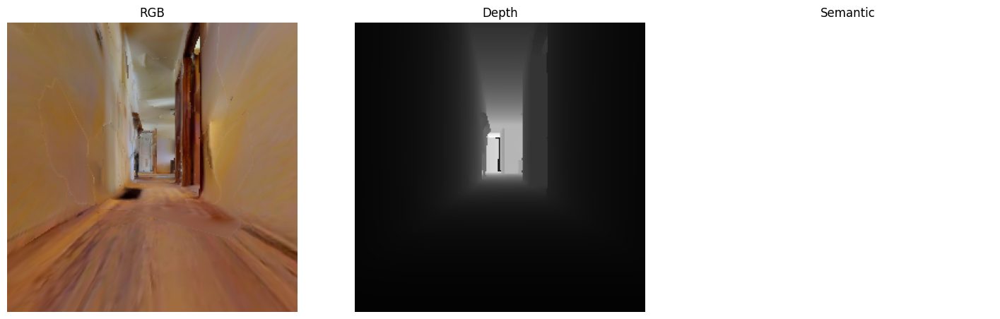

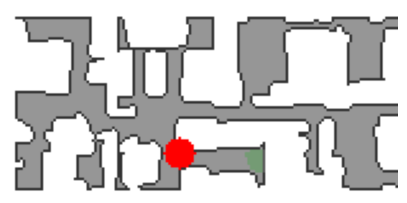

Agent world position: Vector(-2.75573, 0.158252, -1.8434)
Ball world position : Vector(0.00230843, 0.155167, -3.91663)
Ball relative to agent: 3.450378656387329


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


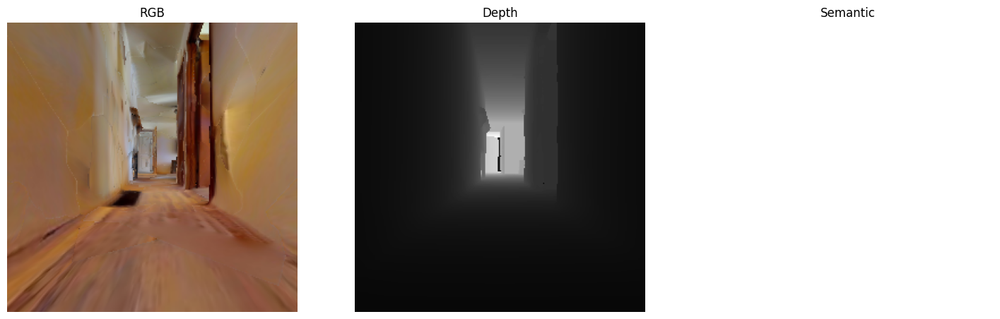

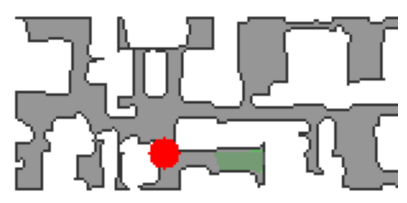

Agent world position: Vector(-3.00573, 0.158252, -1.8434)
Ball world position : Vector(0.00184652, 0.155269, -3.91712)
Ball relative to agent: 3.65320086479187


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


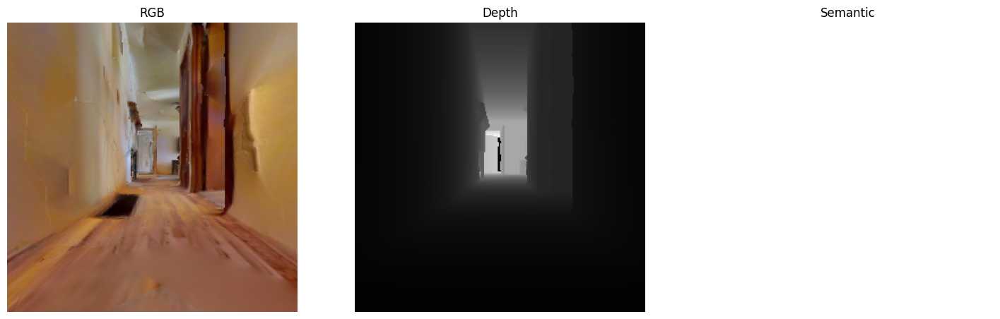

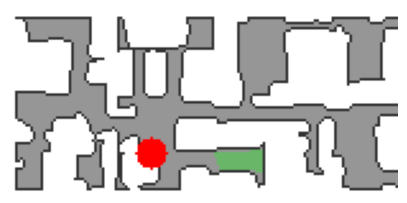

Agent world position: Vector(-3.25573, 0.158252, -1.8434)
Ball world position : Vector(0.00137089, 0.155331, -3.91759)
Ball relative to agent: 3.861478805541992


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


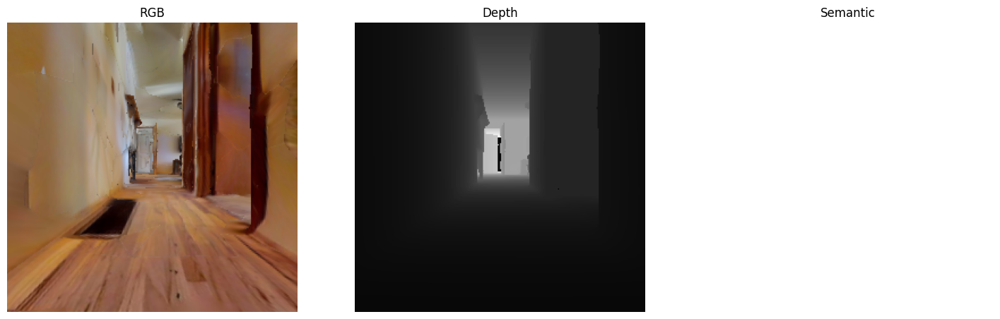

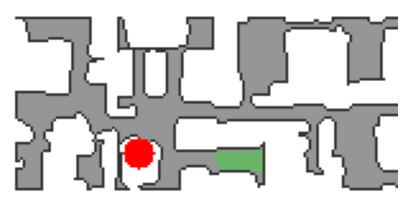

Agent world position: Vector(-3.50573, 0.158252, -1.8434)
Ball world position : Vector(0.000881059, 0.155389, -3.91804)
Ball relative to agent: 4.074371337890625


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


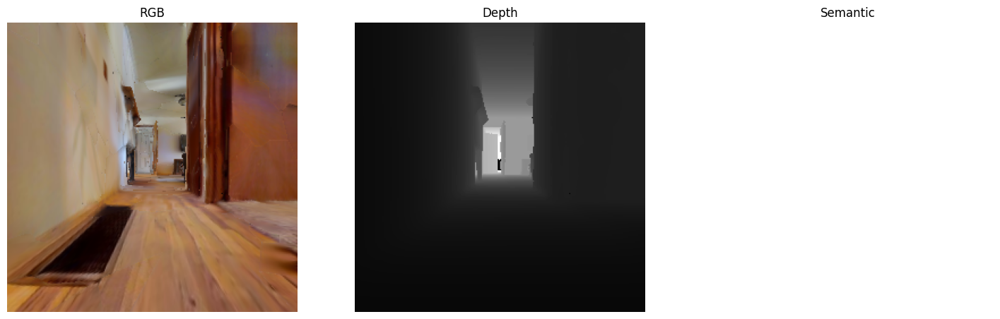

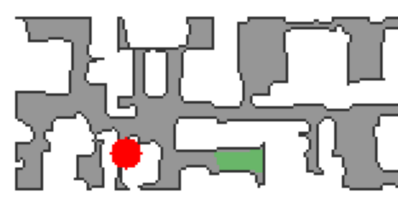

Agent world position: Vector(-3.75573, 0.158252, -1.8434)
Ball world position : Vector(0.000385074, 0.155426, -3.91847)
Ball relative to agent: 4.291196346282959


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


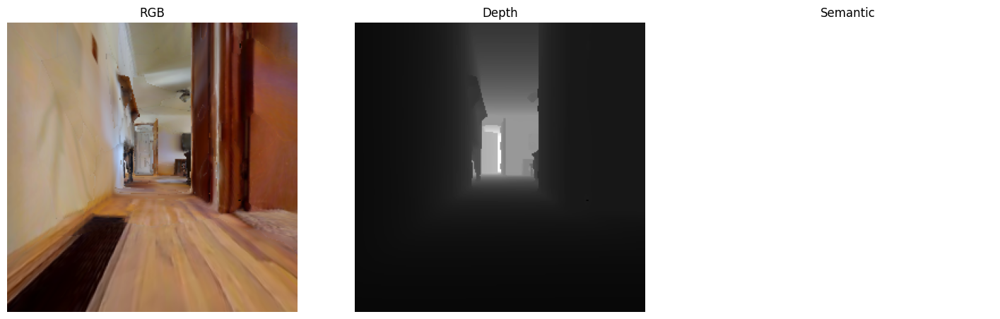

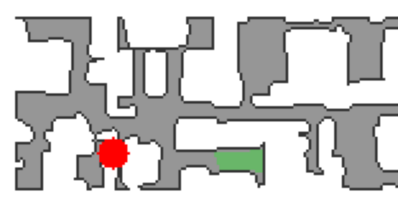

Agent world position: Vector(-4.00573, 0.158252, -1.8434)
Ball world position : Vector(-0.000119707, 0.155452, -3.91889)
Ball relative to agent: 4.511386394500732


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


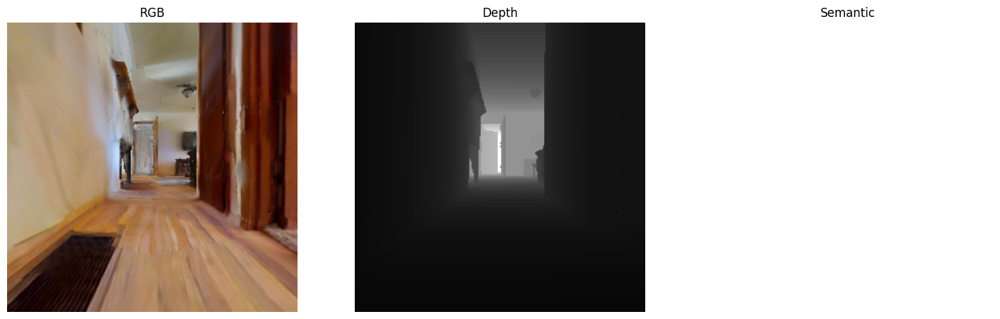

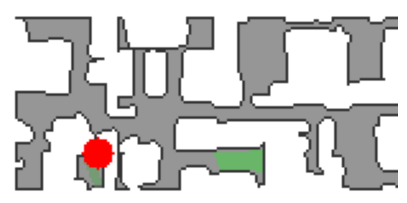

Agent world position: Vector(-4.25573, 0.158252, -1.8434)
Ball world position : Vector(-0.000638377, 0.155464, -3.91929)
Ball relative to agent: 4.734467029571533


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


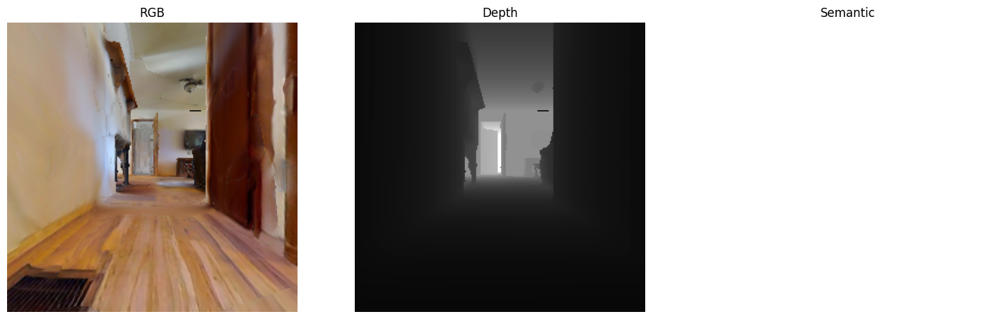

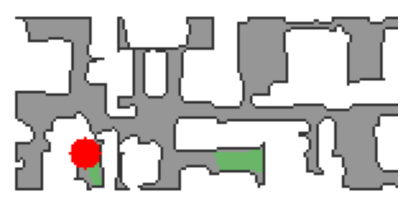

Agent world position: Vector(-4.50573, 0.158252, -1.8434)
Ball world position : Vector(-0.00117741, 0.155461, -3.91969)
Ball relative to agent: 4.9600419998168945


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


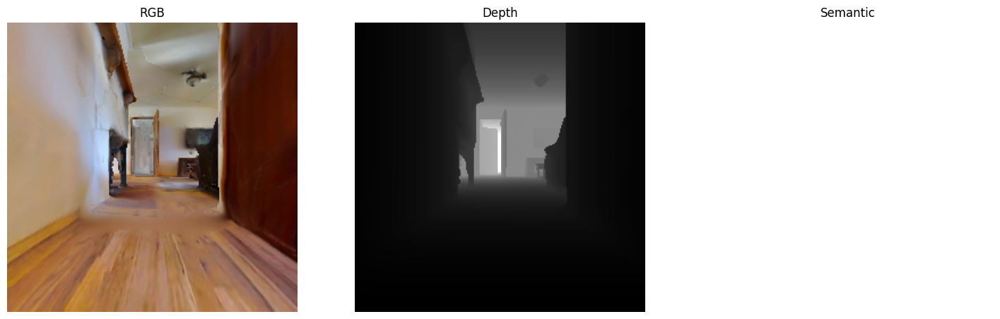

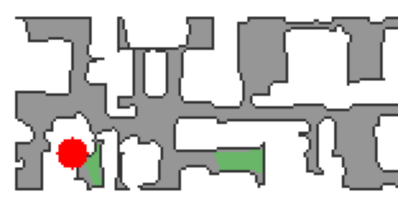

Agent world position: Vector(-4.75573, 0.158252, -1.8434)
Ball world position : Vector(-0.0017264, 0.155476, -3.92007)
Ball relative to agent: 5.187788963317871


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


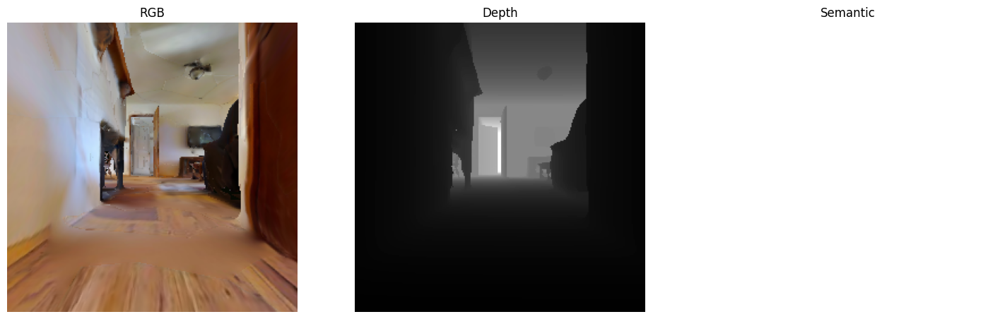

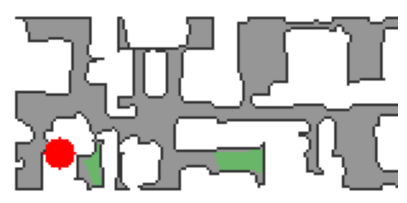

Agent world position: Vector(-5.00573, 0.158252, -1.8434)
Ball world position : Vector(-0.00228291, 0.155491, -3.92044)
Ball relative to agent: 5.417436599731445


Use TGFH to control the agent now:  t


Choose to move_forward
Unique semantic values: [0]


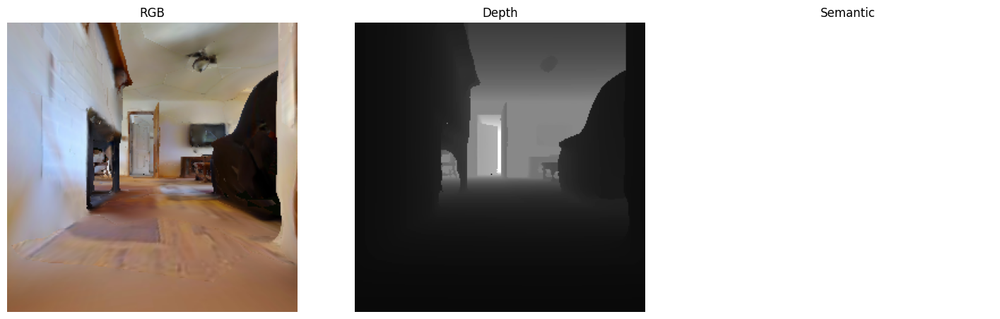

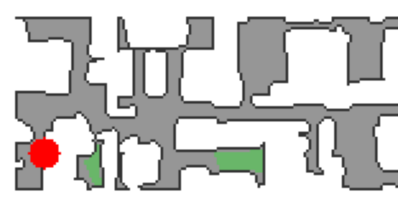

Agent world position: Vector(-5.25573, 0.158252, -1.8434)
Ball world position : Vector(-0.00285299, 0.155494, -3.9208)
Ball relative to agent: 5.648747444152832


In [ ]:
ball_finder = HabitatSimBuilder()
sim_settings = ball_finder.make_default_settings()
sim_settings["scene"] = "data/scene_datasets/cantwell/Cantwell.glb"
sim_settings["sensor_pitch"] = 0

cfg = ball_finder.make_cfg(sim_settings)
# clean-up the current simulator instance if it exists
if ball_finder.sim != None:
    ball_finder.sim.close()
# initialize the simulator
ball_finder.sim = habitat_sim.Simulator(cfg)
obs = ball_finder.sim.reset()
print(">>>>>>>> Instantiated sim")

print(">>>>>>>>> ball_finder.sim = ", ball_finder.sim)
ball_finder.remove_all_objects()
observations = []

# Set agent state
sp = ShortestPath()
pf = ball_finder.sim.pathfinder
start_pt = pf.get_random_navigable_point()
end_pt   = pf.get_random_navigable_point()

for i in range(10):
    print("start random point = ", start_pt)
    print("end random point = ", end_pt)
    start_pt = pf.get_random_navigable_point()
    end_pt   = pf.get_random_navigable_point()


sp.requested_start = Vector3(start_pt)
sp.requested_end = Vector3(end_pt)

success = pf.find_path(sp)
print("start to end navigable ? ", success)

agent = ball_finder.sim.agents[0] # Get our default agent
agent_state = habitat_sim.AgentState()
agent_state.position = Vector3(start_pt)  # Position in world coordinate
agent.set_state(agent_state)

# add a box with default semanticId configured in the template
# Note: each face of this box asset is a separate component

# Managers of various Attributes templates
ball_finder.obj_attr_mgr = ball_finder.sim.get_object_template_manager()
ball_finder.prim_attr_mgr = ball_finder.sim.get_asset_template_manager()
#stage_attr_mgr = ball_finder.sim.get_stage_template_manager()

ball_template = habitat_sim.attributes.ObjectAttributes()
ball_template.render_asset_handle = str(
    os.path.join(os.getcwd(), "data/objects/ball/ball.glb")
)
ball_template.scale = np.array([1.0, 1.0, 1.0])

# set the default semantic id for this object template
ball_template.semantic_id = 1  # @param{type:"integer"}
ball_template_id = ball_finder.obj_attr_mgr.register_template(ball_template, "ball")

#ball_id = ball_finder.sim.add_object(ball_template_id)
rigid_mgr = ball_finder.sim.get_rigid_object_manager()
ball_finder.ball_id = rigid_mgr.add_object_by_template_id(ball_template_id)
ball_finder.object_ids.append(ball_finder.ball_id)
'''ball_finder.set_object_state_from_agent(
    ball_finder.sim, ball_template_id, mn.Vector3(1.5, 0, 1.5), orientation=object_orientation
)'''

'''offset = np.array([0.00005, 0.00001, -0.15])
agent_transform = ball_finder.sim.agents[0].scene_node.transformation_matrix()
ob_translation = agent_transform.transform_point(offset)'''
ball_finder.ball_id.translation = Vector3(end_pt)       # setter on ManagedBulletRigidObject
ball_finder.sim.step_physics(1.0 / 60.0)
ball_finder.make_simulator_from_settings(sim_settings)

new_obs = ball_finder.sim.get_sensor_observations()
rgb_obs = new_obs["color_sensor"]
depth_obs = new_obs["depth_sensor"]
semantic_obs = new_obs["semantic_sensor"]
ball_finder.display_obs(rgb_obs, depth_obs, semantic_obs)


# Récupérer et afficher la position monde de la balle
# ball_obj est le ManagedRigidObject retourné par add_object_by_template_id
print(f"Ball world position : {ball_finder.ball_id.translation}")  

# Récupérer et afficher la position monde de l'agent
agent_node = ball_finder.sim.agents[0].scene_node
agent_mat  = agent_node.absolute_transformation()  # Magnum Matrix4
agent_pos  = agent_mat.translation              # Magnum Vector3
print(f"Agent world position: {agent_pos}")        


# Et la différence relative
rel = ball_finder.ball_id.translation - agent_pos
print(f"Ball relative to agent: {rel}")

observations.append(ball_finder.sim.get_sensor_observations())
#print("observation = ", observations)

key_bindings = {
    'T': 'move_forward',
    'G': 'move_backward',
    'F': 'turn_left',
    'H': 'turn_right',
}
while True:
    key_pressed = input('Use TGFH to control the agent now: ')
    key_pressed = key_pressed.upper()
    if key_pressed == 'O':
        print("Bye...")
        break
    elif key_pressed in key_bindings.keys():
        action = key_bindings[key_pressed]
        print(f"Choose to {action}")
        # TODO: Please enter your code here to replace ...
        # HINT: You can refer to the doc of Env at https://aihabitat.org/docs/habitat-lab/habitat.core.env.Env.html
        
        observations = ball_finder.sim.step(action)
        rgb_obs = observations["color_sensor"]
        depth_obs = observations["depth_sensor"]
        semantic_obs = observations["semantic_sensor"]
        print("Unique semantic values:", np.unique(semantic_obs))
        ball_finder.display_obs(rgb_obs, depth_obs, semantic_obs)
        agent_mat  = agent_node.absolute_transformation()  # Magnum Matrix4
        agent_pos  = agent_mat.translation              # Magnum Vector3

        # Simule un lidar 2D sur la ligne centrale
        '''angles, scan = ball_finder.get_360_lidar_scan(ball_finder.sim)

        plt.figure(figsize=(6,4))
        plt.plot(angles, scan, ".-")
        plt.xlabel("Angle (rad)")
        plt.ylabel("Distance (m)")
        plt.title("Scan 2D simulé depuis la depth cam")
        plt.grid(True)
        plt.show()'''

        ball_finder.render_map()

        print(f"Agent world position: {agent_pos}")  
        print(f"Ball world position : {ball_finder.ball_id.translation}")
        rel = ball_finder.get_agent_to_ball_dist()
        print(f"Ball relative to agent: {rel}")


    else:
        print(f"Invalid input {key_pressed}. Please only use TGFH!")